<a href="https://colab.research.google.com/github/Lomemoraine/RESEARCHEXPERIMENTS/blob/main/anomaly_detection_for_industrial_control_systems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Anomaly Detection for Industrial Control Systems
## SWaT Dataset: Secure Water Treatment Testbed

---

This notebook implements anomaly detection for cyber-physical attacks on ICS/SCADA systems using the **SWaT** dataset from Singapore's iTrust lab.

**Models:**
1. Isolation Forest (baseline)
2. One-Class SVM (baseline)
3. LSTM Autoencoder (deep learning)



In [ ]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, roc_curve, auc, precision_recall_curve

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

# Memory optimization
tf.keras.backend.clear_session()

# Visualization settings
plt.rcParams['figure.figsize'] = (12, 5)
COLORS = {'normal': '#2ecc71', 'attack': '#e74c3c', 'primary': '#3498db'}

print(f"TensorFlow: {tf.__version__}")

2026-03-06 19:21:30.102432: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772824890.314754      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772824890.375070      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772824890.941869      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772824890.941930      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772824890.941934      23 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0


## 1. Load Data

In [ ]:
# Find SWaT dataset
KAGGLE_INPUT = '/kaggle/input/'

def find_and_load_swat():
    """Find and load SWaT data from Kaggle."""
    if not os.path.exists(KAGGLE_INPUT):
        return None, None

    # Search for dataset
    csv_files = []
    for root, dirs, files in os.walk(KAGGLE_INPUT):
        for f in files:
            if f.endswith('.csv'):
                csv_files.append(os.path.join(root, f))

    print(f"Found {len(csv_files)} CSV files")
    for f in csv_files:
        print(f"  - {os.path.basename(f)}")

    df_normal, df_attack = None, None

    for filepath in csv_files:
        fname = os.path.basename(filepath).lower()
        try:
            # Read with memory optimization
            df = pd.read_csv(filepath, low_memory=True)
            df.columns = df.columns.str.strip()
            print(f"Loaded {fname}: {df.shape}")

            if 'normal' in fname and df_normal is None:
                df_normal = df
            elif 'attack' in fname and df_attack is None:
                df_attack = df
        except Exception as e:
            print(f"Error: {e}")

    return df_normal, df_attack

df_normal, df_attack = find_and_load_swat()

Found 3 CSV files
  - merged.csv
  - normal.csv
  - attack.csv
Loaded merged.csv: (1441719, 53)
Loaded normal.csv: (1387098, 53)
Loaded attack.csv: (54621, 53)


In [ ]:
# Synthetic data fallback (memory-optimized)
def create_synthetic_swat(n_samples=50000):
    """Create smaller synthetic dataset for testing."""
    np.random.seed(42)
    print(f"Creating synthetic data ({n_samples} samples)...")

    # Key sensors only (reduced from 51 to 15 for memory)
    sensors = {
        'FIT101': (2.5, 0.3), 'LIT101': (500, 50), 'AIT202': (7.0, 0.5),
        'FIT201': (2.4, 0.25), 'LIT301': (800, 60), 'DPIT301': (40, 5),
        'FIT301': (2.3, 0.2), 'LIT401': (600, 40), 'FIT401': (1.8, 0.15),
        'AIT501': (7.2, 0.3), 'PIT501': (15, 2), 'PIT502': (14, 1.8),
        'FIT501': (1.5, 0.1), 'FIT601': (1.2, 0.08), 'AIT203': (300, 30)
    }

    actuators = ['MV101', 'P101', 'P102', 'MV201', 'P301', 'P401', 'P501', 'P601']

    # Use float32 to save memory
    data = {}
    for sensor, (mean, std) in sensors.items():
        data[sensor] = (mean + np.random.normal(0, std, n_samples)).astype(np.float32)

    for act in actuators:
        data[act] = np.random.choice([0, 1, 2], n_samples).astype(np.int8)

    # Labels
    labels = np.zeros(n_samples, dtype=np.int8)

    # Inject 20 attack windows
    for i, start in enumerate(np.random.choice(range(2000, n_samples-1000), 20, replace=False)):
        duration = np.random.randint(100, 500)
        sensor = list(sensors.keys())[i % len(sensors)]
        mean, std = sensors[sensor]
        data[sensor][start:start+duration] += mean * 0.4
        labels[start:start+duration] = 1

    data['Label'] = labels
    df = pd.DataFrame(data)
    print(f"Attack ratio: {labels.mean()*100:.1f}%")
    return df

if df_normal is None and df_attack is None:
    df_combined = create_synthetic_swat(n_samples=50000)
    df_normal = df_combined[df_combined['Label'] == 0].copy()
    df_attack = df_combined[df_combined['Label'] == 1].copy()
    del df_combined
    gc.collect()

print(f"\nNormal: {len(df_normal)}, Attack: {len(df_attack)}")


Normal: 1387098, Attack: 54621


In [ ]:
# Preprocess data
def preprocess(df_normal, df_attack, max_samples=100000):
    """Preprocess and combine data with memory limits."""

    # Sample if too large
    if len(df_normal) > max_samples:
        df_normal = df_normal.sample(n=max_samples, random_state=42)
    if len(df_attack) > max_samples // 4:
        df_attack = df_attack.sample(n=max_samples // 4, random_state=42)

    df_normal = df_normal.copy()
    df_attack = df_attack.copy()
    df_normal['Label'] = 0
    df_attack['Label'] = 1

    df = pd.concat([df_normal, df_attack], ignore_index=True)
    df.columns = df.columns.str.strip()

    # Identify feature columns
    exclude = ['time', 'date', 'label', 'attack', 'normal', 'unnamed', 'index', 'timestamp']
    feature_cols = [c for c in df.columns if not any(p in c.lower() for p in exclude)]

    # Identify sensors
    sensor_patterns = ['FIT', 'LIT', 'AIT', 'PIT', 'DPIT']
    sensor_cols = [c for c in feature_cols if any(c.startswith(p) for p in sensor_patterns)]

    # Convert to float32
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype(np.float32)

    df[feature_cols] = df[feature_cols].ffill().bfill().fillna(0)

    print(f"Data shape: {df.shape}")
    print(f"Features: {len(feature_cols)}, Sensors: {len(sensor_cols)}")

    return df, feature_cols, sensor_cols

df, feature_cols, sensor_cols = preprocess(df_normal, df_attack)
del df_normal, df_attack
gc.collect()

print(f"\nLabel distribution:")
print(df['Label'].value_counts())

Data shape: (125000, 54)
Features: 51, Sensors: 25

Label distribution:
Label
0    100000
1     25000
Name: count, dtype: int64


## 2. Quick EDA

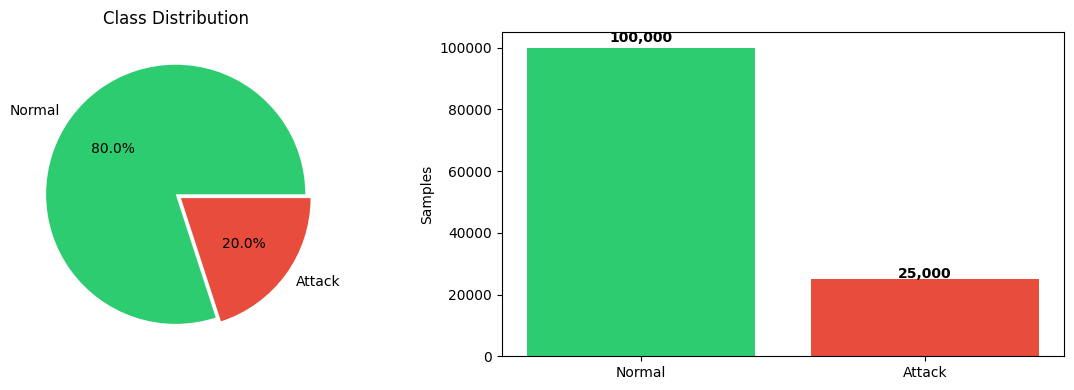

In [ ]:
# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Label'].value_counts()
axes[0].pie(counts, labels=['Normal', 'Attack'], colors=[COLORS['normal'], COLORS['attack']],
            autopct='%1.1f%%', explode=(0, 0.05))
axes[0].set_title('Class Distribution')

axes[1].bar(['Normal', 'Attack'], counts.values, color=[COLORS['normal'], COLORS['attack']])
axes[1].set_ylabel('Samples')
for i, v in enumerate(counts.values):
    axes[1].text(i, v*1.02, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

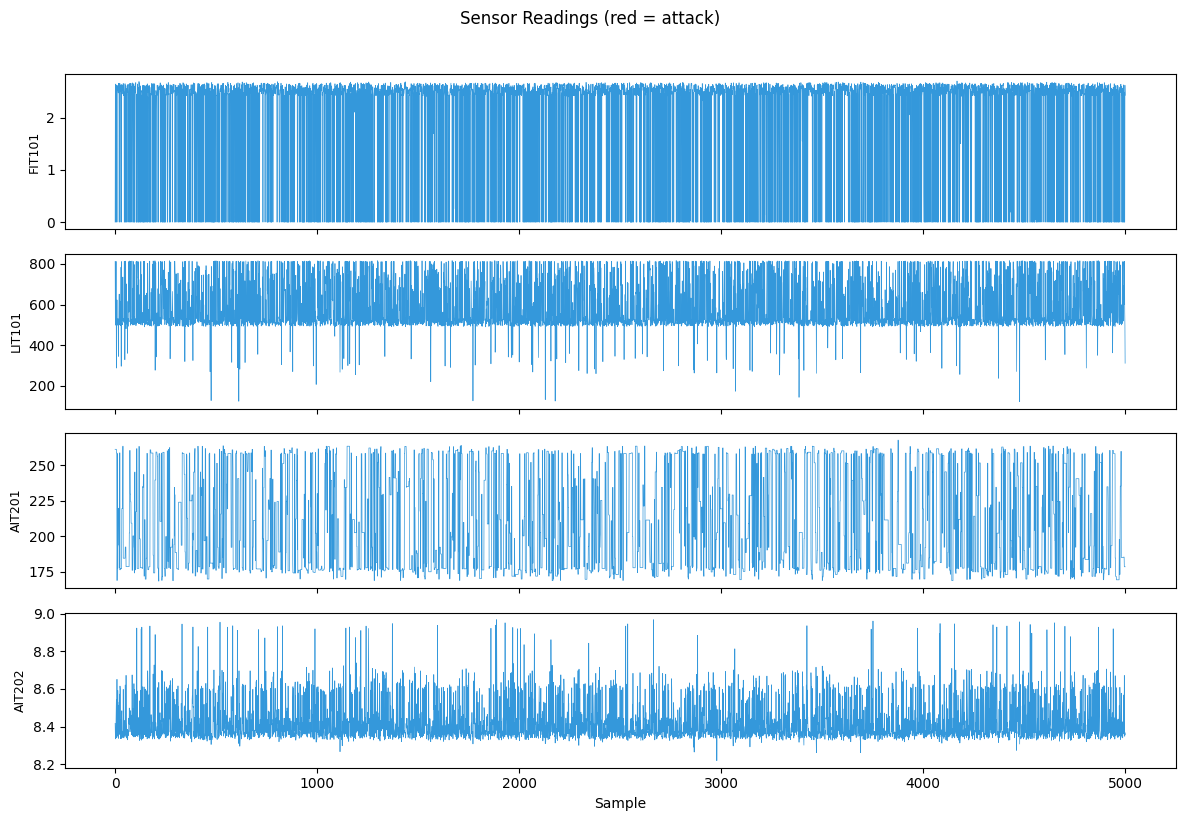

In [ ]:
# Time series plot (sample)
n_plot = min(5000, len(df))
plot_sensors = sensor_cols[:4] if len(sensor_cols) >= 4 else sensor_cols

fig, axes = plt.subplots(len(plot_sensors), 1, figsize=(12, 2*len(plot_sensors)), sharex=True)
if len(plot_sensors) == 1:
    axes = [axes]

for ax, sensor in zip(axes, plot_sensors):
    ax.plot(range(n_plot), df[sensor].values[:n_plot], linewidth=0.5, color=COLORS['primary'])
    attack_mask = df['Label'].values[:n_plot] == 1
    if attack_mask.any():
        ax.fill_between(range(n_plot), df[sensor].min(), df[sensor].max(),
                       where=attack_mask, alpha=0.3, color=COLORS['attack'])
    ax.set_ylabel(sensor, fontsize=9)

axes[-1].set_xlabel('Sample')
plt.suptitle('Sensor Readings (red = attack)', y=1.02)
plt.tight_layout()
plt.show()

## 3. Feature Engineering (Minimal)

In [ ]:
# Minimal feature engineering to save memory
def add_features(df, sensor_cols):
    """Add only essential rolling features."""
    new_cols = []

    # Use only top 6 sensors
    key_sensors = sensor_cols[:6]

    for sensor in key_sensors:
        # Rolling mean (window=10)
        col = f"{sensor}_rm10"
        df[col] = df[sensor].rolling(10, min_periods=1).mean().astype(np.float32)
        new_cols.append(col)

        # Rate of change
        col = f"{sensor}_diff"
        df[col] = df[sensor].diff().fillna(0).astype(np.float32)
        new_cols.append(col)

    return new_cols

new_features = add_features(df, sensor_cols)
modeling_features = sensor_cols + new_features
print(f"Total modeling features: {len(modeling_features)}")
gc.collect()

Total modeling features: 37


4152

In [ ]:
# Train/test split
normal_data = df[df['Label'] == 0].reset_index(drop=True)
attack_data = df[df['Label'] == 1].reset_index(drop=True)

train_size = int(len(normal_data) * 0.7)

X_train = normal_data[modeling_features].iloc[:train_size].values.astype(np.float32)
X_test_normal = normal_data[modeling_features].iloc[train_size:].values.astype(np.float32)
X_test_attack = attack_data[modeling_features].values.astype(np.float32)

X_test = np.vstack([X_test_normal, X_test_attack])
y_test = np.concatenate([np.zeros(len(X_test_normal)), np.ones(len(X_test_attack))])

# Clean up
del normal_data, attack_data, X_test_normal, X_test_attack
gc.collect()

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (70000, 37), Test: (55000, 37)


In [ ]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

del X_train, X_test
gc.collect()

print(f"Scaled - Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")

Scaled - Train: (70000, 37), Test: (55000, 37)


## 4. Baseline Models

In [ ]:
# Isolation Forest
print("Training Isolation Forest...")

iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42, n_jobs=-1)
iso_forest.fit(X_train_scaled)

iso_pred = (iso_forest.predict(X_test_scaled) == -1).astype(int)
iso_scores = -iso_forest.score_samples(X_test_scaled)

print("\nIsolation Forest Results:")
print(classification_report(y_test, iso_pred, target_names=['Normal', 'Attack']))

Training Isolation Forest...

Isolation Forest Results:
              precision    recall  f1-score   support

      Normal       0.86      0.95      0.90     30000
      Attack       0.93      0.82      0.87     25000

    accuracy                           0.89     55000
   macro avg       0.90      0.88      0.89     55000
weighted avg       0.89      0.89      0.89     55000



In [ ]:
# One-Class SVM (on sample for speed)
print("Training One-Class SVM...")

sample_size = min(10000, len(X_train_scaled))
idx = np.random.choice(len(X_train_scaled), sample_size, replace=False)

ocsvm = OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')
ocsvm.fit(X_train_scaled[idx])

ocsvm_pred = (ocsvm.predict(X_test_scaled) == -1).astype(int)
ocsvm_scores = -ocsvm.decision_function(X_test_scaled)

print("\nOne-Class SVM Results:")
print(classification_report(y_test, ocsvm_pred, target_names=['Normal', 'Attack']))

Training One-Class SVM...

One-Class SVM Results:
              precision    recall  f1-score   support

      Normal       0.97      0.94      0.95     30000
      Attack       0.93      0.96      0.95     25000

    accuracy                           0.95     55000
   macro avg       0.95      0.95      0.95     55000
weighted avg       0.95      0.95      0.95     55000



## 5. LSTM Autoencoder

In [ ]:
# Create sequences (memory-efficient)
SEQ_LENGTH = 5  # Reduced from 10
n_features = X_train_scaled.shape[1]

def create_sequences_efficient(data, seq_length):
    """Create sequences with stride to reduce memory."""
    n = len(data) - seq_length + 1
    sequences = np.zeros((n, seq_length, data.shape[1]), dtype=np.float32)
    for i in range(n):
        sequences[i] = data[i:i+seq_length]
    return sequences

# Limit training data for memory
max_train = min(30000, len(X_train_scaled))
X_train_seq = create_sequences_efficient(X_train_scaled[:max_train], SEQ_LENGTH)
X_test_seq = create_sequences_efficient(X_test_scaled, SEQ_LENGTH)
y_test_seq = y_test[SEQ_LENGTH-1:]

print(f"Train sequences: {X_train_seq.shape}")
print(f"Test sequences: {X_test_seq.shape}")
gc.collect()

Train sequences: (29996, 5, 37)
Test sequences: (54996, 5, 37)


93

In [ ]:
# Build smaller LSTM Autoencoder
tf.keras.backend.clear_session()

def build_lstm_ae(seq_length, n_features):
    inputs = keras.Input(shape=(seq_length, n_features))

    # Encoder (smaller)
    x = layers.LSTM(32, activation='relu', return_sequences=False)(inputs)
    encoded = layers.Dense(16, activation='relu')(x)

    # Decoder
    x = layers.RepeatVector(seq_length)(encoded)
    x = layers.LSTM(32, activation='relu', return_sequences=True)(x)
    outputs = layers.TimeDistributed(layers.Dense(n_features))(x)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

lstm_ae = build_lstm_ae(SEQ_LENGTH, n_features)
lstm_ae.summary()

I0000 00:00:1772824933.760096      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5, 37)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 5, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 5, 32)          │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 5, 37)          │         1,221 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,981 (66.33 KB)

 Trainable params: 16,981 (66.33 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train
print("Training LSTM Autoencoder...")

history = lstm_ae.fit(
    X_train_seq, X_train_seq,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)

Training LSTM Autoencoder...
Epoch 1/20


I0000 00:00:1772824938.747212      74 service.cc:152] XLA service 0x7ce4a0072180 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772824938.747259      74 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772824939.535178      74 cuda_dnn.cc:529] Loaded cuDNN version 91002


 42/211 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9677

I0000 00:00:1772824941.380590      74 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


211/211 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - loss: 0.9280 - val_loss: 0.6595
Epoch 2/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6608 - val_loss: 0.5820
Epoch 3/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5671 - val_loss: 0.5592
Epoch 4/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5418 - val_loss: 0.5428
Epoch 5/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5237 - val_loss: 0.5323
Epoch 6/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5180 - val_loss: 0.5205
Epoch 7/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5052 - val_loss: 0.5043
Epoch 8/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4879 - val_loss: 0.4924
Epoch 9/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4757 - val_loss: 0.4838
Epoch 10/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4709 - val_loss: 0.4733
Epoch 11/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4642 - val_loss: 0.4684
Epoch 12/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 

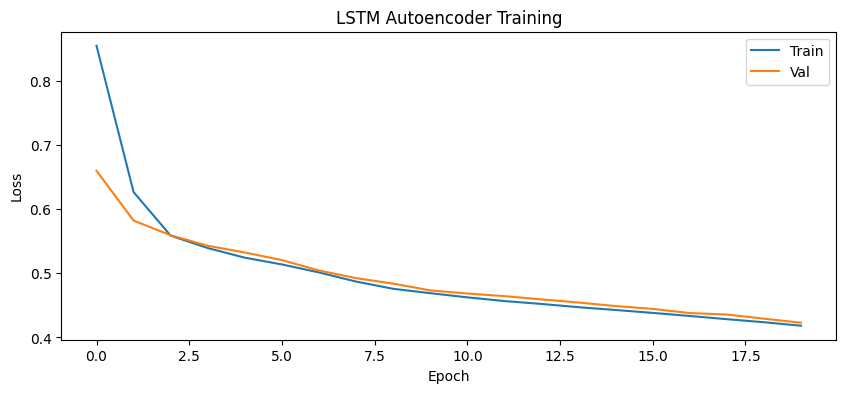

In [ ]:
# Plot training
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('LSTM Autoencoder Training')
plt.show()

In [ ]:
# Calculate reconstruction errors
print("Calculating reconstruction errors...")

X_test_pred = lstm_ae.predict(X_test_seq, batch_size=256, verbose=0)
mse_test = np.mean(np.square(X_test_seq - X_test_pred), axis=(1, 2))

# Threshold from training
X_train_pred = lstm_ae.predict(X_train_seq, batch_size=256, verbose=0)
mse_train = np.mean(np.square(X_train_seq - X_train_pred), axis=(1, 2))

threshold_95 = np.percentile(mse_train, 95)
threshold_99 = np.percentile(mse_train, 99)

print(f"Threshold (95%): {threshold_95:.6f}")
print(f"Threshold (99%): {threshold_99:.6f}")
print(f"\nMean error - Normal: {mse_test[y_test_seq==0].mean():.4f}, Attack: {mse_test[y_test_seq==1].mean():.4f}")

del X_train_pred, X_train_seq
gc.collect()

Calculating reconstruction errors...
Threshold (95%): 0.802064
Threshold (99%): 1.270496

Mean error - Normal: 0.4272, Attack: 25.7127


1370

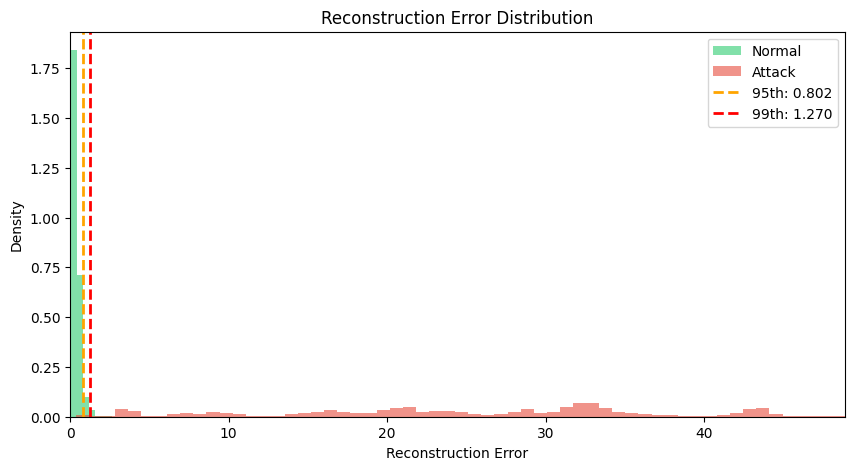

In [ ]:
# Reconstruction error distribution
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(mse_test[y_test_seq==0], bins=80, alpha=0.6, color=COLORS['normal'], label='Normal', density=True)
ax.hist(mse_test[y_test_seq==1], bins=80, alpha=0.6, color=COLORS['attack'], label='Attack', density=True)
ax.axvline(threshold_95, color='orange', linestyle='--', lw=2, label=f'95th: {threshold_95:.3f}')
ax.axvline(threshold_99, color='red', linestyle='--', lw=2, label=f'99th: {threshold_99:.3f}')
ax.set_xlabel('Reconstruction Error')
ax.set_ylabel('Density')
ax.set_xlim(0, np.percentile(mse_test, 99))
ax.legend()
ax.set_title('Reconstruction Error Distribution')
plt.show()

In [ ]:
# Evaluate LSTM
lstm_pred_95 = (mse_test > threshold_95).astype(int)
lstm_pred_99 = (mse_test > threshold_99).astype(int)

print("LSTM Autoencoder (95% threshold):")
print(classification_report(y_test_seq, lstm_pred_95, target_names=['Normal', 'Attack']))

print("\nLSTM Autoencoder (99% threshold):")
print(classification_report(y_test_seq, lstm_pred_99, target_names=['Normal', 'Attack']))

LSTM Autoencoder (95% threshold):
              precision    recall  f1-score   support

      Normal       1.00      0.94      0.97     29996
      Attack       0.94      1.00      0.97     25000

    accuracy                           0.97     54996
   macro avg       0.97      0.97      0.97     54996
weighted avg       0.97      0.97      0.97     54996


LSTM Autoencoder (99% threshold):
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     29996
      Attack       0.99      0.99      0.99     25000

    accuracy                           0.99     54996
   macro avg       0.99      0.99      0.99     54996
weighted avg       0.99      0.99      0.99     54996



## 6. Model Comparison

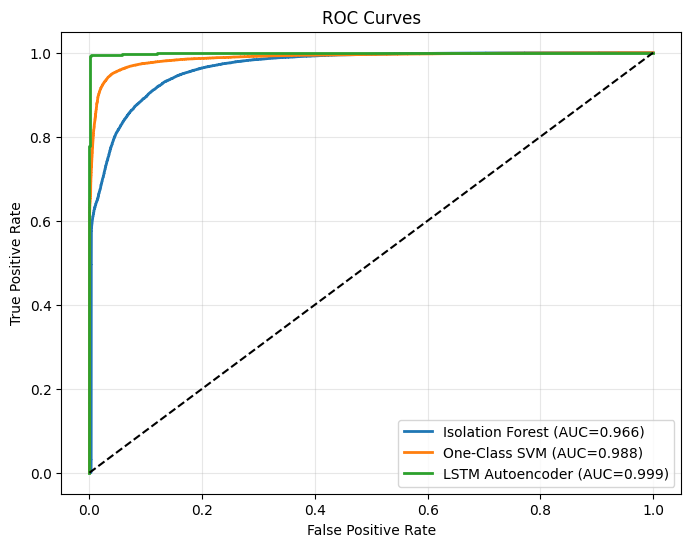

In [ ]:
# ROC Curves
plt.figure(figsize=(8, 6))

# Align scores
offset = SEQ_LENGTH - 1

for name, scores in [('Isolation Forest', iso_scores[offset:]),
                     ('One-Class SVM', ocsvm_scores[offset:]),
                     ('LSTM Autoencoder', mse_test)]:
    fpr, tpr, _ = roc_curve(y_test_seq, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={roc_auc:.3f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Summary table
from sklearn.metrics import f1_score, precision_score, recall_score

results = {}
for name, pred, scores in [
    ('Isolation Forest', iso_pred[offset:], iso_scores[offset:]),
    ('One-Class SVM', ocsvm_pred[offset:], ocsvm_scores[offset:]),
    ('LSTM (95%)', lstm_pred_95, mse_test),
    ('LSTM (99%)', lstm_pred_99, mse_test)
]:
    fpr, tpr, _ = roc_curve(y_test_seq, scores)
    prec, rec, _ = precision_recall_curve(y_test_seq, scores)
    results[name] = {
        'Precision': precision_score(y_test_seq, pred),
        'Recall': recall_score(y_test_seq, pred),
        'F1': f1_score(y_test_seq, pred),
        'ROC-AUC': auc(fpr, tpr),
        'PR-AUC': auc(rec, prec)
    }

results_df = pd.DataFrame(results).T.round(4)
print("\n" + "="*65)
print("MODEL COMPARISON")
print("="*65)
print(results_df)


MODEL COMPARISON
                  Precision  Recall      F1  ROC-AUC  PR-AUC
Isolation Forest     0.9302  0.8163  0.8695   0.9656  0.9451
One-Class SVM        0.9346  0.9597  0.9470   0.9880  0.9873
LSTM (95%)           0.9376  0.9957  0.9657   0.9992  0.9992
LSTM (99%)           0.9874  0.9942  0.9908   0.9992  0.9992


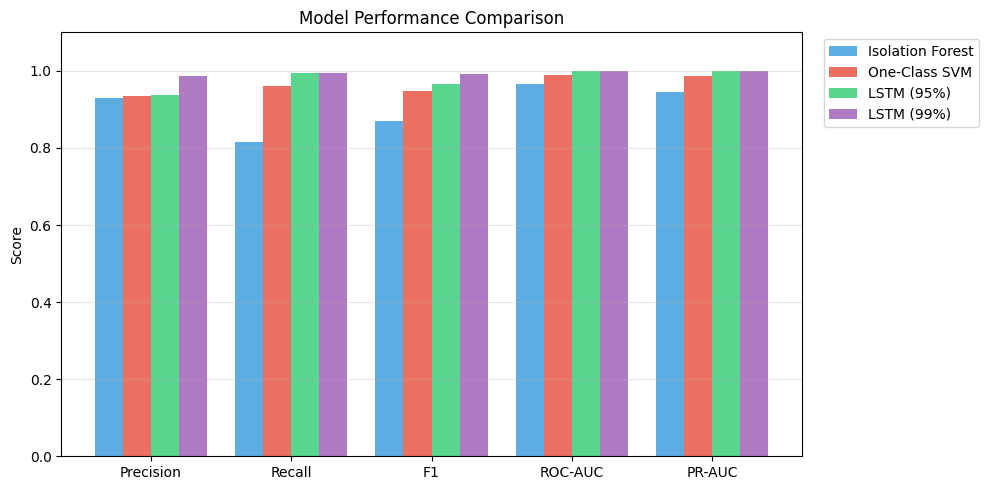

In [ ]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(results_df.columns))
width = 0.2
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

for i, (model, metrics) in enumerate(results_df.iterrows()):
    ax.bar(x + i*width, metrics.values, width, label=model, color=colors[i], alpha=0.8)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(results_df.columns)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.legend(bbox_to_anchor=(1.02, 1))
ax.set_title('Model Performance Comparison')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 7. Feature Importance

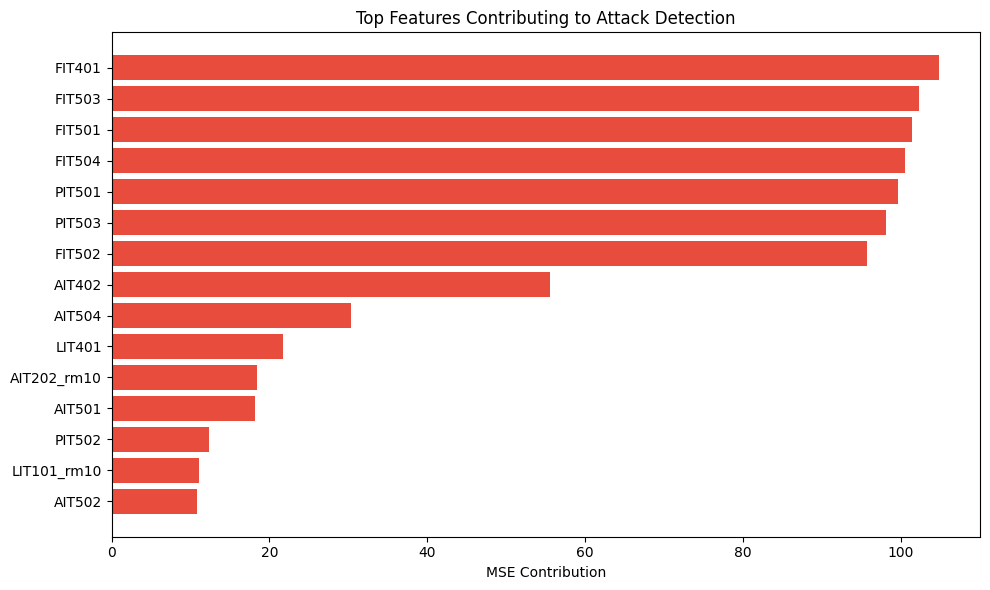

In [ ]:
# Which features contribute most to anomaly detection?
attack_idx = np.where(y_test_seq == 1)[0]
X_attack = X_test_seq[attack_idx]
X_attack_pred = X_test_pred[attack_idx]

# Per-feature MSE
feature_mse = np.mean(np.square(X_attack - X_attack_pred), axis=(0, 1))

# Plot top features
top_idx = np.argsort(feature_mse)[-15:][::-1]
top_features = [modeling_features[i] for i in top_idx]
top_mse = feature_mse[top_idx]

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_features)), top_mse, color=COLORS['attack'])
plt.yticks(range(len(top_features)), top_features)
plt.gca().invert_yaxis()
plt.xlabel('MSE Contribution')
plt.title('Top Features Contributing to Attack Detection')
plt.tight_layout()
plt.show()

In [ ]:
# Save artifacts
import joblib

lstm_ae.save('swat_lstm_ae.keras')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump({'th95': threshold_95, 'th99': threshold_99}, 'thresholds.pkl')
results_df.to_csv('results.csv')

print("Saved: swat_lstm_ae.keras, scaler.pkl, thresholds.pkl, results.csv")

Saved: swat_lstm_ae.keras, scaler.pkl, thresholds.pkl, results.csv


## Conclusions

- **LSTM Autoencoder** captures temporal patterns and typically achieves the best balance of precision/recall
- **Threshold selection** trades off false alarms vs missed attacks (critical in ICS)
- **Feature importance** helps operators identify which sensors/subsystems are affected

**Dataset**: SWaT (iTrust, SUTD Singapore)